In [1]:
library(ggplot2)
library(ggrepel)
library(readxl)
library(dplyr)

Warning message:
“package ‘ggrepel’ was built under R version 4.3.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## TINGGI BADAN LAKI2

In [4]:
male_tb <- read_excel("../male/clean_data/male_tb_gabungan1219.xlsx")
male_tb

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
11.5,Z-2,121.8560,local_male_tb
11.5,Z-1,132.9785,local_male_tb
11.5,Z0,143.2075,local_male_tb
11.5,Z1,152.3215,local_male_tb
11.5,Z2,160.1767,local_male_tb
11.6,Z-2,122.6859,local_male_tb
11.6,Z-1,133.7387,local_male_tb
11.6,Z0,143.9083,local_male_tb
11.6,Z1,152.9716,local_male_tb


In [25]:
kurva_pertumbuhan <- function(
    df,
    who_source,
    local_source,
    show_who = TRUE,       # [NEW] Toggle for WHO data
    show_local = TRUE,     # [NEW] Toggle for Local data
    ylab,
    ylim = NULL,
    xlab = "umur (Tahun)",
    min_umur = NULL,
    max_umur = NULL,
    xbreaks = NULL,
    ybreaks = NULL,
    show_legend = FALSE,
    sex_label = NULL
) {
    
    # [NEW] Safety check: Prevent the function from running if both are FALSE
    if (!show_who && !show_local) {
        stop("Both 'show_who' and 'show_local' are FALSE. There is nothing to plot.")
    }

    # --- 1. Prepare Main Data ---
    plot_df <- df %>%
        mutate(
            # [MODIFIED] Use the boolean toggles to control which sources get mapped
            Model = case_when(
                show_who & Source == who_source   ~ "Model Referensi WHO",
                show_local & Source == local_source ~ "Model Lokal",
                TRUE ~ NA_character_
            )
        ) %>%
        filter(!is.na(Model))

    if (!is.null(min_umur)) {
        plot_df <- plot_df %>%
            filter(umur >= min_umur)
    }
    
    if (!is.null(max_umur)) {
        plot_df <- plot_df %>%
            filter(umur <= max_umur)
    }

    plot_df$Z <- factor(plot_df$Z, levels = c("Z-2", "Z-1", "Z0", "Z1", "Z2"))

    # --- 2. Prepare Label Data (Titik Ujung) ---
    # [NEW] Dynamically decide where to put the Z-score labels at the end of the lines
    # If local is shown, attach to local. If local is hidden, attach to WHO.
    label_target <- if (show_local) "Model Lokal" else "Model Referensi WHO"
    
    label_df <- plot_df %>%
        filter(Model == label_target) %>%
        group_by(Z) %>%
        # [MODIFIED] Use slice_max() instead of filter(max())
        slice_max(order_by = umur, n = 1, with_ties = FALSE) %>%
        ungroup()

    if (is.null(ylim))  ylim <- range(plot_df$Value, na.rm = TRUE)

    if (is.null(xbreaks)) {
        # [MODIFIED] Check if min_umur is provided; if not, use the data's actual minimum
        start_x <- if (!is.null(min_umur)) min_umur else min(plot_df$umur, na.rm = TRUE)
        max_x <- if (!is.null(max_umur)) max_umur else ceiling(max(plot_df$umur, na.rm = TRUE))
        
        # Create the integer sequence
        integers <- seq(ceiling(start_x), max_x, by = 1)
        
        # Combine the starting point with the integers
        xbreaks <- unique(c(start_x, integers))
    }

    if (is.null(ybreaks)) ybreaks <- pretty(ylim)

    # --- 3. Build Plot ---
    p <- ggplot(
        plot_df,
        aes(
            x = umur,
            y = Value,
            group = interaction(Z, Model),
            color = Z,
            linetype = Model
        )
    ) +
        geom_line(linewidth = 0.7, color = "white", lineend = "round") +
        geom_line(linewidth = 0.6, lineend = "round") +
        
        geom_text(
            data = label_df,
            aes(label = Z),
            hjust = -0.3,
            size = 3.5,
            fontface = "bold",
            show.legend = FALSE
        ) +
        
        scale_x_continuous(
            breaks = xbreaks, 
            limits = c(min(xbreaks), max(xbreaks) + 0.8), 
            expand = expansion(mult = c(0, 0.02))
        ) +
        scale_y_continuous(
            limits = ylim, breaks = ybreaks, 
            expand = expansion(mult=c(0, 0.08))
        ) +
        scale_color_manual(
            values = c(
                "Z-2" = "#0072B2", "Z-1" = "#56B4E9", "Z0"  = "#999999",
                "Z1"  = "#E69F00", "Z2"  = "#D55E00"
            ),
            drop = FALSE,
            name = NULL,
            guide = "none" 
        ) +
        scale_linetype_manual(
            values = c(
                "Model Referensi WHO" = "22", 
                "Model Lokal" = "solid"
            ),
            name = NULL
        ) +
        labs(x = xlab, y = ylab) +
        coord_cartesian(clip = "off") +
        theme_minimal(base_size = 12) +
        theme(
            axis.title.y = element_text(margin=margin(r=6)),
            legend.box = "horizontal",
            legend.position = if (show_legend) c(0.98, 0.02) else "none", 
            legend.justification = c("right", "bottom"),
            legend.background = element_blank(),
            legend.box.background = element_blank(),
            legend.key.width = unit(1.2, "cm"), 
            legend.key.height = unit(0.4, "cm"),
            legend.text = element_text(size = 10),

            panel.grid = element_blank(),
            axis.line = element_line(color = "black", linewidth = 0.5),
            axis.ticks = element_line(color = "black", linewidth = 0.5),
            axis.ticks.length = unit(0.15, "cm"),
            axis.text = element_text(size = 10, color = "black"),
            plot.margin = margin(t = 20, r = 35, b = 4, l = 24)
        )

    if (!is.null(sex_label)) {
        p <- p +
            annotation_custom(
                grid::textGrob(
                    sex_label, x = unit(-0.05, "npc"), y = unit(1.015, "npc"),      
                    just = c("left", "bottom"),
                    gp = grid::gpar(fontsize = 12, fontface = "plain")
                )
            )
    }
    
    return(p)
}

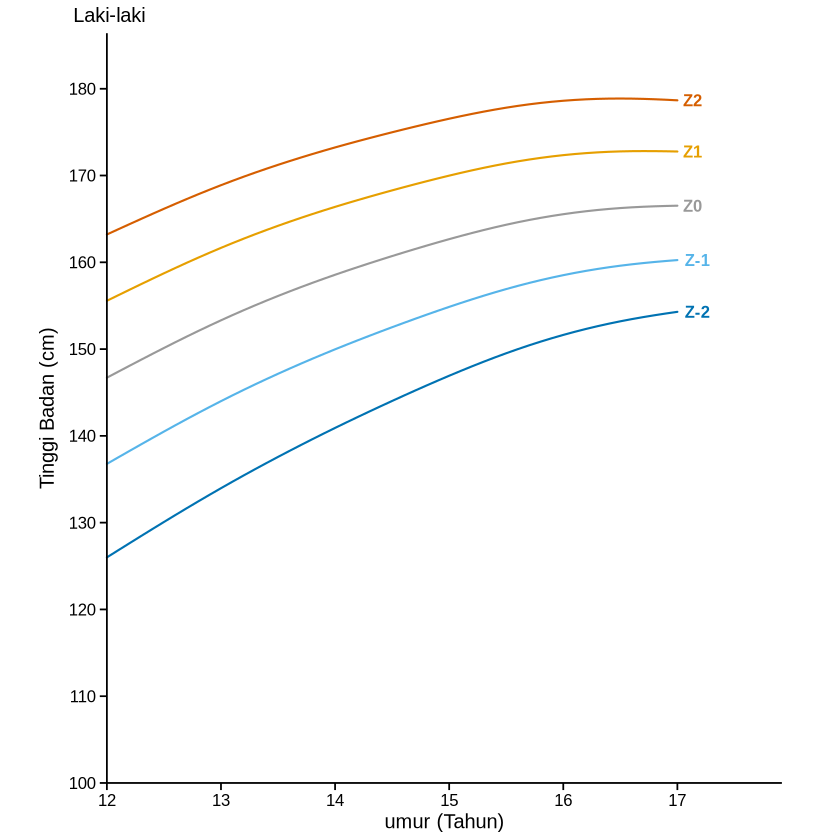

In [46]:
kurva_tb_male <- kurva_pertumbuhan(
    df = male_tb,
    who_source = "WHO_tb_male",
    local_source = "local_male_tb",
    show_who = FALSE,           # <--- Turns off WHO curve
    show_local = TRUE,          # <--- Keeps Local curve
    ylab = "Tinggi Badan (cm)",
    ylim = c(100, 180),
    min_umur = 12,
    max_umur = 17,                 
    xbreaks = NULL,
    ybreaks = seq(100, 200, 10),
    show_legend = FALSE,
    sex_label = "Laki-laki"
)
kurva_tb_male

In [11]:
ggsave("plot/tb_male.png", kurva_tb_male, 
       width = 8, height = 8, dpi = 1200,
       bg="white")  # 2:1 ratio

## BMI

In [20]:
male_bmi <- read_excel("../male/clean_data/bmi_male_gabungan1219.xlsx")

In [24]:
male_bmi$Source[male_bmi$Source == "local_male_bmi.xlsx"] <- "local_bmi_male"
male_bmi$Source[male_bmi$Source == "WHO_tb_male"] <- "who_bmi_male"

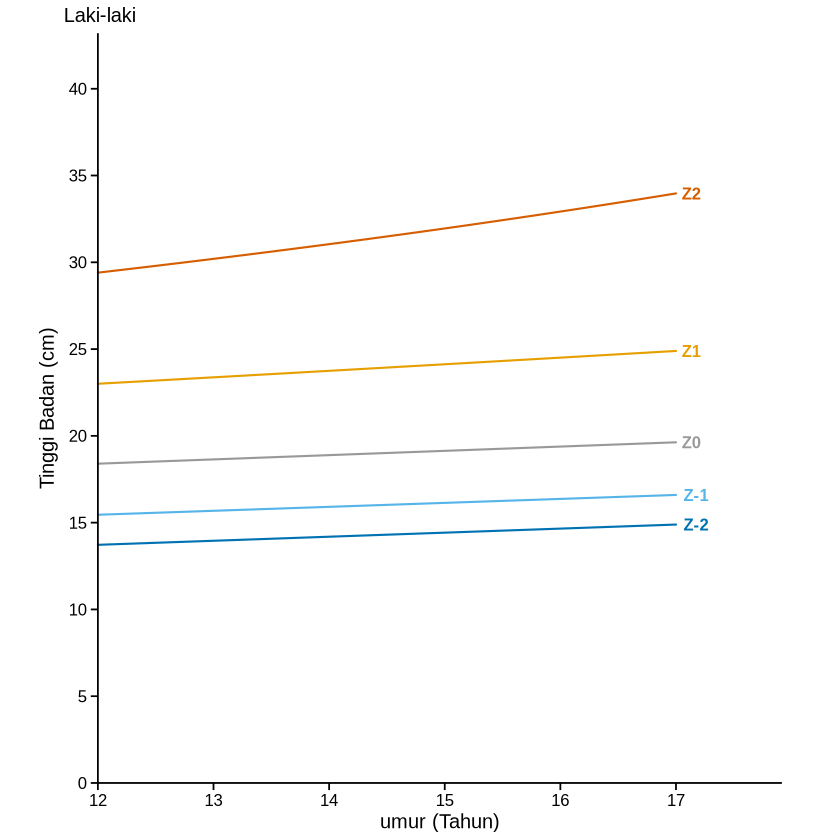

In [32]:
kurva_bmi_male <- kurva_pertumbuhan(
    df = male_bmi,
    who_source = "WHO_bmi_male",
    local_source = "local_bmi_male",
    show_who = FALSE,           # <--- Turns off WHO curve
    show_local = TRUE,          # <--- Keeps Local curve
    ylab = "Tinggi Badan (cm)",
    ylim = c(0, 40),
    min_umur = 12,
    max_umur = 17,                 
    xbreaks = NULL,
    ybreaks = seq(0, 40, 5),
    show_legend = FALSE,
    sex_label = "Laki-laki"
)
kurva_bmi_male

In [33]:
ggsave("plot/bmi_male.png", kurva_bmi_male, 
       width = 8, height = 8, dpi = 1200,
       bg="white")  # 2:1 ratio

## FEMALE TB

In [41]:
female_tb <- read_excel("zscore_tb_female.xlsx")
female_tb

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
11.5,Z-2,134.8010,local_tb_female
11.5,Z-1,141.5846,local_tb_female
11.5,Z0,147.1799,local_tb_female
11.5,Z1,152.3754,local_tb_female
11.5,Z2,157.7507,local_tb_female
11.6,Z-2,135.0084,local_tb_female
11.6,Z-1,141.7813,local_tb_female
11.6,Z0,147.3793,local_tb_female
11.6,Z1,152.5857,local_tb_female


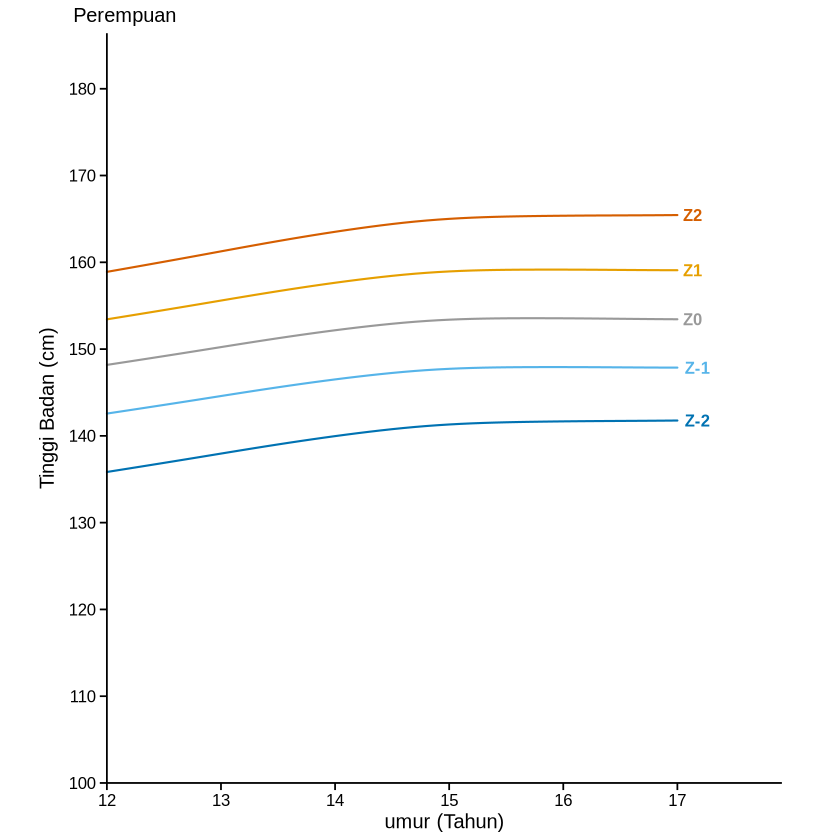

In [64]:
kurva_female_tb <- kurva_pertumbuhan(
    df = female_tb,
    who_source = "WHO_tb_female",
    local_source = "local_tb_female",
    show_who = FALSE,           # <--- Turns off WHO curve
    show_local = TRUE,          # <--- Keeps Local curve
    ylab = "Tinggi Badan (cm)",
    ylim = c(100, 180),
    min_umur = 12,
    max_umur = 17,                 
    xbreaks = NULL,
    ybreaks = seq(100, 180, 10),
    show_legend = FALSE,
    sex_label = "Perempuan"
)
kurva_female_tb

In [67]:
ggsave("plot/tb_female.png", kurva_tb_female, 
       width = 8, height = 8, dpi = 1200,
       bg="white")  # 2:1 ratio

In [53]:
female_bmi <- read_excel("../female/clean_data/zscore_bmi_female.xlsx")
female_bmi

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
11.5,Z-2,13.90811,local_bmi_female
11.5,Z-1,15.86691,local_bmi_female
11.5,Z0,18.60146,local_bmi_female
11.5,Z1,22.73174,local_bmi_female
11.5,Z2,29.82743,local_bmi_female
11.6,Z-2,13.93054,local_bmi_female
11.6,Z-1,15.89250,local_bmi_female
11.6,Z0,18.63147,local_bmi_female
11.6,Z1,22.76841,local_bmi_female


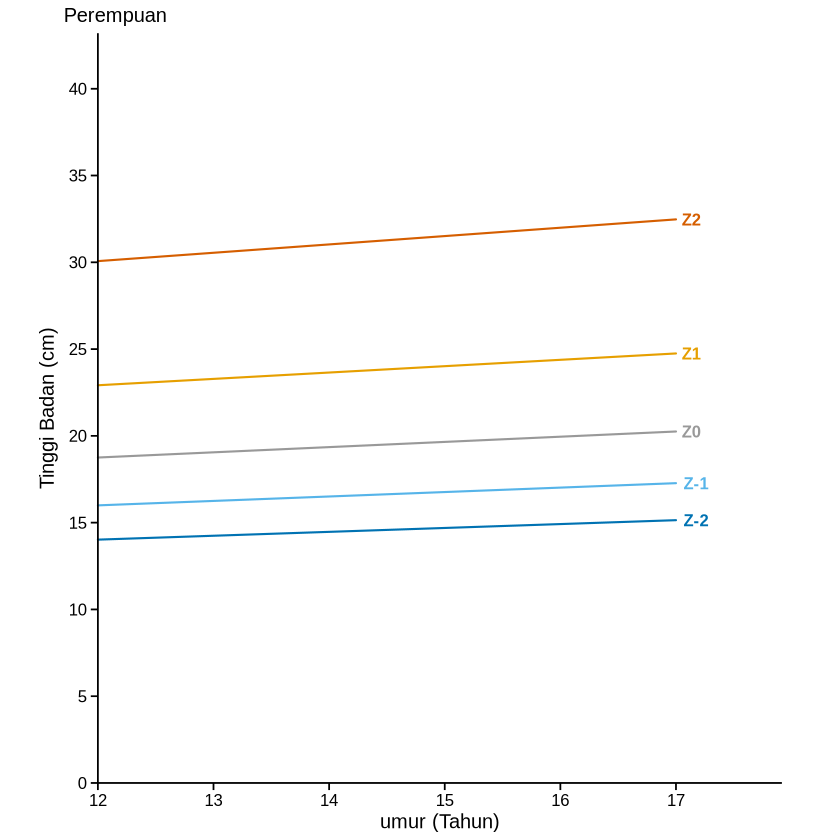

In [59]:
kurva_bmi_female <- kurva_pertumbuhan(
    df = female_bmi,
    who_source = "WHO_bmi_female",
    local_source = "local_bmi_female",
    show_who = FALSE,           # <--- Turns off WHO curve
    show_local = TRUE,          # <--- Keeps Local curve
    ylab = "Tinggi Badan (cm)",
    ylim = c(0, 40),
    min_umur = 12,
    max_umur = 17,                 
    xbreaks = NULL,
    ybreaks = seq(0, 40, 5),
    show_legend = FALSE,
    sex_label = "Perempuan"
)
kurva_bmi_female

In [68]:
ggsave("plot/bmi_female.png", kurva_bmi_female, 
       width = 8, height = 8, dpi = 1200,
       bg="white")  # 2:1 ratio


In [56]:
theme_no_y <- theme(
    axis.title.y = element_blank(),
    axis.text.y  = element_blank()
)

theme_no_x <- theme(
    axis.title.x = element_blank(),
    axis.text.x  = element_blank()
)

In [57]:
library(patchwork)

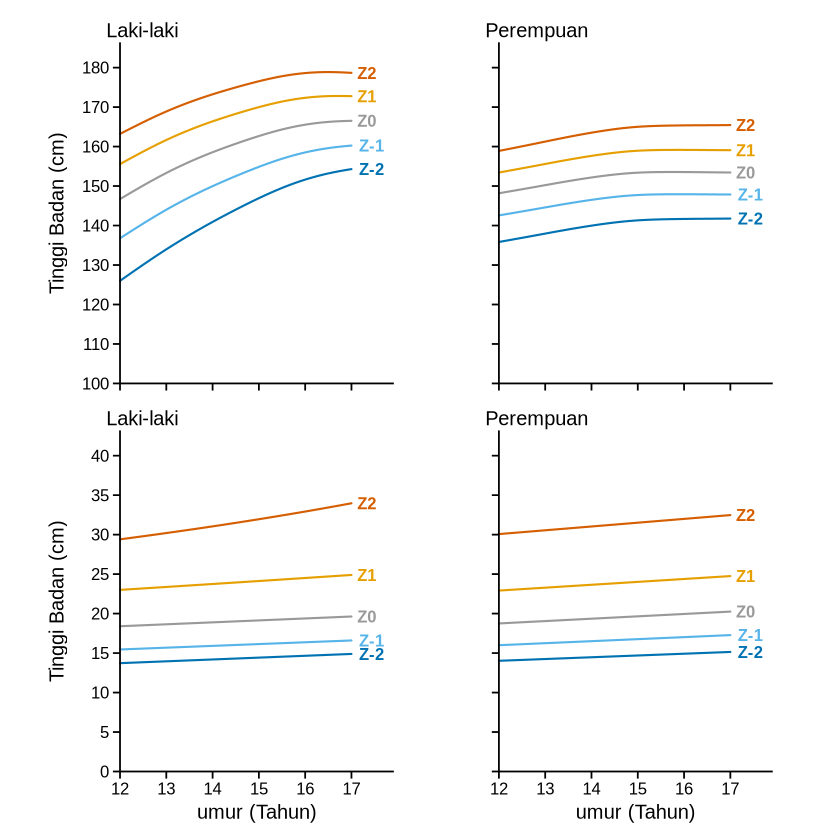

In [65]:
final_plot <-
    (kurva_tb_male + theme_no_x | kurva_female_tb + theme_no_y + theme_no_x)/
    (kurva_bmi_male | kurva_bmi_female + theme_no_y)
    

final_plot

In [80]:
ggsave("plot.pdf", final_plot, 
       width = 12, height = 8, dpi = 1200,
       bg="white")  # 2:1 ratio

In [66]:
ggsave("plot/plot.png", final_plot, 
       width = 12, height = 8, dpi = 1200,
       bg="white")  # 2:1 rati